In [ ]:
# Uncomment if needed
# !pip install importlib
# !pip install importlib-metadata

In [ ]:
import subprocess
import sys
from importlib_metadata import version as pkg_version, PackageNotFoundError

packages = ["torch", "torchvision", "torchaudio", "tqdm", "matplotlib", "scikit-learn", "seaborn", "kagglehub", "ipywidgets"]

print("####################################################################")
print("Checking packages and upgrading only if needed (local check)...")
print("-----------------------------------")

for pkg in packages:
    try:
        installed_version = pkg_version(pkg)
        print(f"{pkg} is installed (version {installed_version}). Checking for upgrade...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", pkg])
    except PackageNotFoundError:
        print(f"{pkg} is not installed. Installing now...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

print("####################################################################")

####################################################################
Checking packages and upgrading only if needed (local check)...
-----------------------------------
torch is installed (version 2.10.0+cu128). Checking for upgrade...
torchvision is installed (version 0.25.0+cu128). Checking for upgrade...
torchaudio is installed (version 2.10.0+cu128). Checking for upgrade...
tqdm is installed (version 4.67.3). Checking for upgrade...
matplotlib is installed (version 3.10.0). Checking for upgrade...
scikit-learn is installed (version 1.6.1). Checking for upgrade...
seaborn is installed (version 0.13.2). Checking for upgrade...
kagglehub is installed (version 0.3.13). Checking for upgrade...
ipywidgets is installed (version 7.7.1). Checking for upgrade...
####################################################################


In [ ]:
# Handle imports
import os
import torch
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import time
import kagglehub
import utils
import copy
import matplotlib.pyplot as plt
from tqdm import tqdm
import shutil
import seaborn as sns

In [ ]:
print("####################################################################################")
print("Hello!!! Thank you for using OCT Classification.")
env = input("Please tell me if you are running code on Kaggle, colab or Local? (kaggle/colab/local): ").strip().lower()

model_name="resnet"
prev_stage=None

path_final_models , path_hackathon_checkpoints, path_plots, path_oct_models = utils.create_paths(model_name=model_name, augmented=True, env=env)

####################################################################################
Hello!!! Thank you for using OCT Classification.
Please tell me if you are running code on Kaggle, colab or Local? (kaggle/colab/local): colab
Mounted at /content/drive
Running in Colab environment.
The path are:
Final Models: /content/drive/MyDrive/Final_Models/resnet_aug
Hackathon Checkpoints: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug
Plots: /content/drive/MyDrive/plots/resnet_aug
OCT Models: /content/drive/MyDrive/oct_models/resnet_aug


In [ ]:
# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("####################################################################")
print("Using device:", device)
print("####################################################################")

####################################################################
Using device: cpu
####################################################################


In [ ]:
# Download dataset if needed
DATA_PATH = kagglehub.dataset_download("mislamshawon/oct2017")
print("####################################################################################")
print("The path for the dataset is:", DATA_PATH)
print("####################################################################")

# Check folder exists
if os.path.exists(DATA_PATH):
    print("Data folder contents:", os.listdir(os.path.join(DATA_PATH)))
    print("####################################################################")
    print("Train folder contents:", os.listdir(os.path.join(DATA_PATH, "train")))
    print("####################################################################")
    print("Val folder contents:", os.listdir(os.path.join(DATA_PATH, "val")))
    print("####################################################################")
    print("Test folder contents:", os.listdir(os.path.join(DATA_PATH, "test")))
    print("####################################################################")
else:
    print("Path does not exist!")

# Set random seed = 42
rand_seed = 42
np.random.seed(rand_seed)
torch.manual_seed(rand_seed)
torch.cuda.manual_seed_all(rand_seed)

Using Colab cache for faster access to the 'oct2017' dataset.
####################################################################################
The path for the dataset is: /kaggle/input/oct2017
####################################################################
Data folder contents: ['val', 'test', 'train']
####################################################################
Train folder contents: ['DRUSEN', 'CNV', 'NORMAL', 'DME']
####################################################################
Val folder contents: ['DRUSEN', 'CNV', 'NORMAL', 'DME']
####################################################################
Test folder contents: ['DRUSEN', 'CNV', 'NORMAL', 'DME']
####################################################################


In [ ]:
# Define the High-Speed Path
KAGGE_CACHE = DATA_PATH
RAM_DISK_PATH = '/dev/shm/oct2017'

# Move it to RAM
if not os.path.exists(RAM_DISK_PATH):
    print("Moving dataset to RAM disk for maximum speed...")
    shutil.copytree(KAGGE_CACHE, RAM_DISK_PATH)
    print("Done!")

# Update DATA_PATH variable
DATA_PATH = RAM_DISK_PATH

Moving dataset to RAM disk for maximum speed...
Done!


In [ ]:
torch.set_float32_matmul_precision('high')

In [ ]:
# Create separate DataFrames
train_df = utils.create_dataframe("train", DATA_PATH)
val_df   = utils.create_dataframe("val", DATA_PATH)
test_df  = utils.create_dataframe("test", DATA_PATH)

sum_total_data = len(train_df)+len(val_df)+len(test_df)
print("####################################################################")
print("The total images in the dataset are:", (sum_total_data), "images")
print("####################################################################")

print("####################################################################")
print("The size of the imported data in each folder is:")
print("A) Train size:", len(train_df),"images [",len(train_df)/(sum_total_data) *100,"% ]")
print("B) Validation size:", len(val_df),"images [",len(val_df)/(sum_total_data) *100,"% ]")
print("C) Test size:", len(test_df),"images [",len(test_df)/(sum_total_data) *100,"% ]")
print("####################################################################")

####################################################################
The total images in the dataset are: 84130 images
####################################################################
####################################################################
The size of the imported data in each folder is:
A) Train size: 50580 images [ 60.12124093664567 % ]
B) Validation size: 16851 images [ 20.029715915844527 % ]
C) Test size: 16699 images [ 19.849043147509807 % ]
####################################################################


In [ ]:
# Encode Labels to Numbers
le = LabelEncoder()

train_df["label_encoded"] = le.fit_transform(train_df["label"])
val_df["label_encoded"] = le.transform(val_df["label"])
test_df["label_encoded"] = le.transform(test_df["label"])
print("####################################################################")
print("The names of the classes in OCT classification are:")
print("Classes:", le.classes_)
print("Classes have been labeled as 0, 1, 2, 3.")
print("####################################################################")

####################################################################
The names of the classes in OCT classification are:
Classes: ['CNV' 'DME' 'DRUSEN' 'NORMAL']
Classes have been labeled as 0, 1, 2, 3.
####################################################################


In [ ]:
# Image transformation
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0,translate=(0.05, 0.05),scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transform_val_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# Pass Transform Into Dataset
train_dataset = utils.OCTDataset(train_df, transform=transform)
val_dataset = utils.OCTDataset(val_df, transform=transform_val_test)
test_dataset = utils.OCTDataset(test_df, transform=transform_val_test)

In [ ]:
# Define y_train variable based on labels
y_train = torch.tensor(train_df["label_encoded"].values)

# In order to define the weighted cross entropy loss we need the weights
class_counts = torch.bincount(y_train.cpu()) # Exw upo8esei pws exoume orisei to y_train
num_classes = 4
total_samples = len(y_train)
class_weights = total_samples / (num_classes * class_counts)

class_weights = class_weights.to(device) # Move weights to same device

# Import resnet18 with default weights
model = resnet18(weights=ResNet18_Weights.DEFAULT)
# Replace fc layer for 4 classes
model.fc = nn.Linear(model.fc.in_features, 4)
# Move model to device
model = model.to(device)
print("####################################################################")
print("Model created successfully.")
print("####################################################################")
print("The model creeated is:")
print(model)
print("####################################################################")
print("Check number of total parameters in the model:", sum(p.numel() for p in model.parameters()))
print("####################################################################")

# Define Cross Entropy Loss
criterion = nn.CrossEntropyLoss(weight=class_weights)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 244MB/s]


####################################################################
Model created successfully.
####################################################################
The model creeated is:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, ke

**Comments**

Layer	Output Channels	Meaning

conv1	64	edges

layer1	64	low-level textures

layer2	128	mid-level patterns

layer3	256	structural patterns

layer4	512	semantic features

fc	4	disease classes

In [ ]:
# Use a fraction of data for testing the code
print("####################################################################")
print("What fraction of data do you want to use? [Fraction = 1.0 is for the full dataset]")
FRACTION = float(input("Please give a number between 0 - 1: "))
print("Using FRACTION =", FRACTION,"[", FRACTION*100,"% of all data]")
print("####################################################################")

# Create DataLoaders
print("####################################################################")
while True:
    BATCH_SIZE = int(input("Enter batch size (e.g., 32, 64, 128): "))
    if BATCH_SIZE % 8 != 0 and BATCH_SIZE != 1:
        print("Please enter a batch size that is a multiple of 8")
    else:
        break
print("Using batch size:", BATCH_SIZE)
print("####################################################################")

fraction_train_dataset = utils.get_subset(train_dataset, FRACTION)
fraction_val_dataset   = utils.get_subset(val_dataset, FRACTION)
fraction_test_dataset  = utils.get_subset(test_dataset, FRACTION)

train_loader = DataLoader(fraction_train_dataset, batch_size=BATCH_SIZE, num_workers=8, persistent_workers=True,
                          prefetch_factor=2, shuffle=True, pin_memory=True)
val_loader   = DataLoader(fraction_val_dataset, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
test_loader  = DataLoader(fraction_test_dataset, batch_size=BATCH_SIZE)

sum_fraction_data = (len(fraction_train_dataset)+len(fraction_val_dataset)+len(fraction_test_dataset))

print("####################################################################")
print("Fraction of train data:", len(fraction_train_dataset),"images [",len(fraction_train_dataset)/(sum_total_data)*100,"% ]")
print("Fraction of val data:", len(fraction_val_dataset),"images [",len(fraction_val_dataset)/(sum_total_data)*100,"% ]")
print("Fraction of test data:", len(fraction_test_dataset),"images [",len(fraction_test_dataset)/(sum_total_data)*100,"% ]")
print("####################################################################")
print("Data that will be used are:", sum_fraction_data,"images [",sum_fraction_data/(sum_total_data)*100,"% ]")
print("####################################################################")

####################################################################
What fraction of data do you want to use? [Fraction = 1.0 is for the full dataset]
Please give a number between 0 - 1: 1
Using FRACTION = 1.0 [ 100.0 % of all data]
####################################################################
####################################################################
Enter batch size (e.g., 32, 64, 128): 512
Using batch size: 512
####################################################################
####################################################################
Fraction of train data: 50580 images [ 60.12124093664567 % ]
Fraction of val data: 16851 images [ 20.029715915844527 % ]
Fraction of test data: 16699 images [ 19.849043147509807 % ]
####################################################################
Data that will be used are: 84130 images [ 100.0 % ]
####################################################################


In [ ]:
stages = ['fc','layer4', 'layer3', 'layer2', 'layer1', None]
print("########################################################################################")
print("The defined stages for training oct-classification model are:")
print(stages)
print("#######################################################################################")

########################################################################################
The defined stages for training oct-classification model are:
['fc', 'layer4', 'layer3', 'layer2', 'layer1', None]
#######################################################################################


In [ ]:
print("#################################################################################")
while True:
    try:
        num_epochs = int(input("Please give number of epochs to run at each stage: "))
        if num_epochs <= 0:
            print("Please enter a positive integer.")
            continue
        break
    except ValueError:
        print("Invalid input, please enter a number.")
print("The defined number of epochs is", num_epochs)
print("#################################################################################")

#################################################################################
Please give number of epochs to run at each stage: 15
The defined number of epochs is 15
#################################################################################


In [ ]:
lr = 1e-4  # initial learning rate

print("#" * 129)
print("Please wait until training the \"oct-classification model\" is done.")

prev_stage = None

for stage in tqdm(stages, desc='Stage', unit='stage', position=0, leave=True):
    # Check if stage is completed by finding if best model exists
    best_model_path = os.path.join(path_oct_models, f"resnet18_{stage}_best.pth")
    if os.path.exists(best_model_path):
        print(f"[INFO] Best model for {stage} already exists. Skipping to next stage.")
        prev_stage = stage
        continue

    early_stopping = utils.Early_Stopping()

    # Freeze layers for the stage
    utils.freeze_first_n_layers(model, stage)

    # Setup optimizer & scheduler
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    # Load checkpoint if it exists
    (model, optimizer, scheduler, start_epoch,
     train_epoch_losses, train_epoch_f1s,
     val_epoch_losses, val_epoch_f1s,
     num_epochs_checkpoint, data_fraction_checkpoint) = utils.load_latest_checkpoint(model, optimizer, scheduler, stage, path=path_hackathon_checkpoints)

    if start_epoch == 0 and prev_stage is not None:
        prev_best_model_path = os.path.join(path_oct_models, f"resnet18_{prev_stage}_best.pth")
        if os.path.exists(prev_best_model_path):
            print(f"Loading best model from previous stage: {prev_stage} for stage {stage}")
            model.load_state_dict(torch.load(prev_best_model_path, map_location=device))
        else:
            print(f"No best model found for previous stage: {prev_stage}, starting from current model weights.")

    resumed_lr = optimizer.param_groups[0]['lr']
    stage_start = time.time()
    print(f"Starting stage '{stage}' from epoch {start_epoch + 1} with LR = {resumed_lr:.2e}")
    print("-" * 129)

    for epoch in range(start_epoch, num_epochs):
        epoch_start = time.time()
        print("")
        print("*" * 49, f" Running epoch: {epoch + 1} out of {num_epochs} ", "*" * 52)

        # Train + Evaluate
        train_epoch_loss, train_epoch_f1 = utils.train_model(model, train_loader, criterion, optimizer, device)
        val_epoch_loss, val_epoch_f1 = utils.evaluate(model, val_loader, criterion, device)

        # Update LR
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # Accumulate metrics
        train_epoch_losses.append(train_epoch_loss)
        train_epoch_f1s.append(train_epoch_f1)
        val_epoch_losses.append(val_epoch_loss)
        val_epoch_f1s.append(val_epoch_f1)

        # Save checkpoint
        utils.save_checkpoint(model, optimizer, scheduler, stage, epoch,
                        train_epoch_losses, train_epoch_f1s,
                        val_epoch_losses, val_epoch_f1s,
                        num_epochs=num_epochs,
                        data_fraction=FRACTION,
                        path=path_hackathon_checkpoints)

        epoch_time = time.time() - epoch_start
        print("=" * 129)
        print(
            f"Epoch {epoch + 1} [{stage}]: "
            f"Train Loss = {train_epoch_loss:.4f} | Train F1 = {train_epoch_f1:.4f} | "
            f"Val Loss = {val_epoch_loss:.4f} | Val F1 = {val_epoch_f1:.4f} | "
            f"LR = {current_lr:.2e} | Time = {epoch_time:.2f}s"
        )
        print("=" * 129)

        # Early stopping
        early_stopping(val_epoch_f1, model)
        if early_stopping.early_stop:
            model.load_state_dict(early_stopping.best_state)
            best_model = copy.deepcopy(model)
            utils.save_best_model(best_model, "resnet18", stage, path_to_models=path_oct_models)
            print("!" * 40)
            print(f"Stopping early at epoch {epoch + 1}")
            break

    # Save best model if early stop did not trigger
    if not early_stopping.early_stop:
        model.load_state_dict(early_stopping.best_state)
        best_model = copy.deepcopy(model)
        utils.save_best_model(best_model, "resnet18", stage, path_to_models=path_oct_models)

    prev_stage = stage

    # Plot curves using accumulated metrics (including resumed epochs)
    print(f"\nThe loss and training curves at stage {stage} are:\n")
    utils.loss_train_curve_plots(
        num_epochs=len(train_epoch_losses),
        train_epoch_losses=train_epoch_losses,
        train_epoch_f1s=train_epoch_f1s,
        val_epoch_losses=val_epoch_losses,
        val_epoch_f1s=val_epoch_f1s,
        save_plot=True,
        stage=stage,
        model_name='resnet18',
        augmented=True,
        path_plot=path_plots
    )

    total_stage_time = time.time() - stage_start
    print(f"\nTraining of stage \"{stage}\" completed in {total_stage_time / 60:.2f} minutes.\n")

print("#" * 129)


In [ ]:
# # Setup Temporary Path
# path_temp_checkpoints = os.path.join(os.path.dirname(path_hackathon_checkpoints), "temp_standardized_checkpoints")
# os.makedirs(path_temp_checkpoints, exist_ok=True)

# for stage in stages:
#     stage = str(stage)
#     print(f"\n### Re-grading Stage: {stage} ###")

#     # Get all checkpoint files for this stage
#     ckpt_files = [f for f in os.listdir(path_hackathon_checkpoints) if stage in f and "checkpoint" in f]
#     ckpt_files.sort(key=lambda x: int(x.split('_')[-1].split('.')[0]))

#     corrected_train_f1_list = []
#     corrected_train_loss_list = []

#     for ckpt_file in tqdm(ckpt_files, desc=f"Re-evaluating {stage} Train Set"):
#         ckpt_path = os.path.join(path_hackathon_checkpoints, ckpt_file)
#         temp_path = os.path.join(path_temp_checkpoints, ckpt_file)

#         # Load the checkpoint
#         checkpoint = torch.load(ckpt_path, map_location=device)
#         model.load_state_dict(checkpoint['model_state_dict'])

#         # This replaces the 'weighted' train result from the original run
#         t_loss, t_macro_f1 = utils.evaluate(model, train_loader, criterion, device)

#         # Keep track of the history for this stage
#         corrected_train_loss_list.append(t_loss)
#         corrected_train_f1_list.append(t_macro_f1)

#         # Update the dictionary
#         updated_ckpt = copy.deepcopy(checkpoint)

#         # Update training metrics with the NEW Macro history
#         updated_ckpt['train_epoch_losses'] = corrected_train_loss_list.copy()
#         updated_ckpt['train_epoch_f1s'] = corrected_train_f1_list.copy()

#         # Validation was already correct, so we keep it as is
#         # torch.save the new clean checkpoint
#         torch.save(updated_ckpt, temp_path)

# print(f"\nAll checkpoints in {path_temp_checkpoints} now have consistent Macro Training F1.")


### Re-grading Stage: fc ###


Re-evaluating fc Train Set: 100%|██████████| 9/9 [20:06<00:00, 134.03s/it]



### Re-grading Stage: layer4 ###


Re-evaluating layer4 Train Set: 100%|██████████| 15/15 [33:43<00:00, 134.92s/it]



### Re-grading Stage: layer3 ###


...


### Re-grading Stage: layer1 ###


Re-evaluating layer1 Train Set: 100%|██████████| 15/15 [34:30<00:00, 138.05s/it]



### Re-grading Stage: None ###


Re-evaluating None Train Set: 100%|██████████| 6/6 [14:01<00:00, 140.27s/it]


✅ Success! All checkpoints in /content/drive/MyDrive/hackathon_checkpoints/temp_standardized_checkpoints now have consistent Macro Training F1.


Extracted 69 total epochs across 6 stages.
Best models identified at global epoch indices: [5, 20, 35, 44, 59, 65]


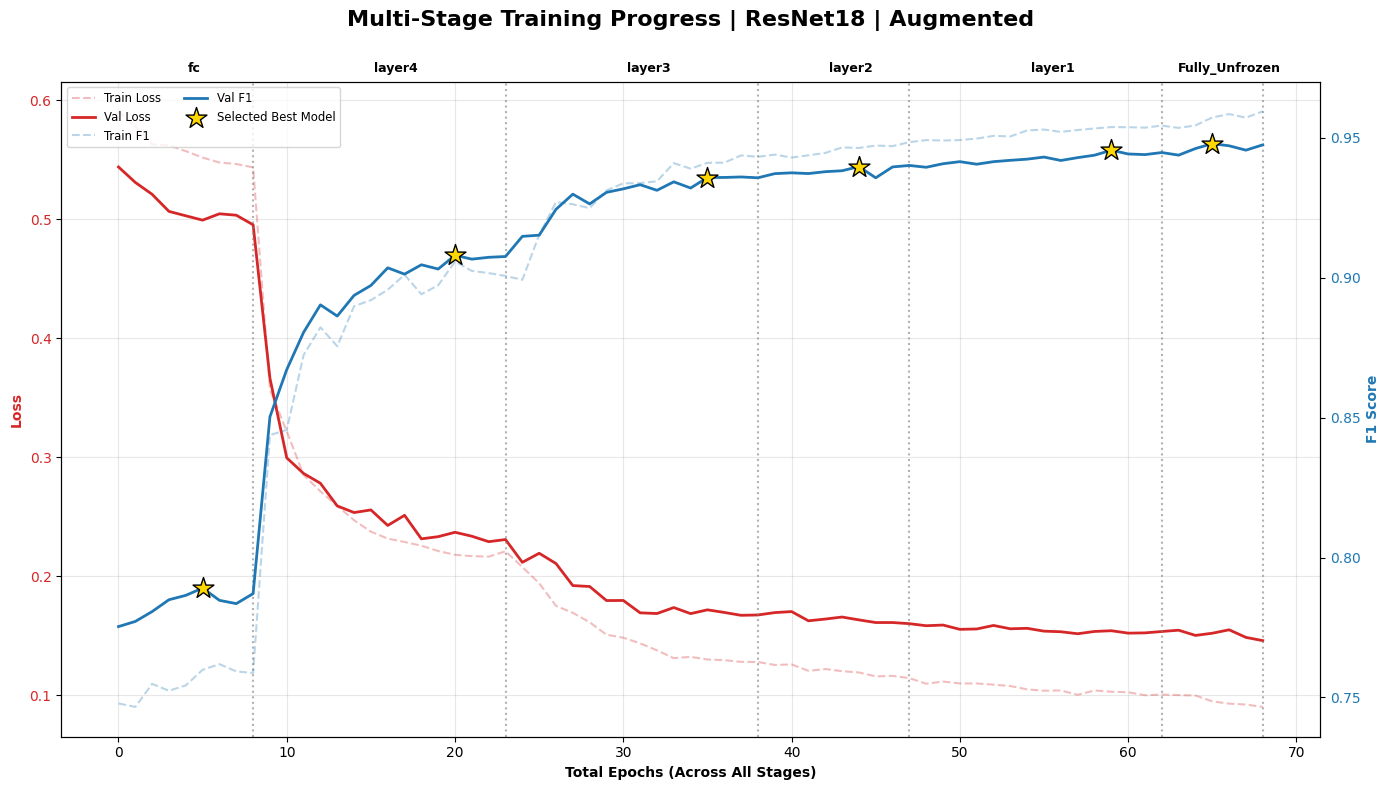

In [ ]:
# Extract all the data from checkpoints
path_temp_checkpoints = os.path.join(os.path.dirname(path_hackathon_checkpoints), "temp_standardized_checkpoints")

metrics_dict = utils.extract_all_metrics(stages, path_temp_checkpoints, "ResNet18")

# Check if data exists
if not metrics_dict['val_loss']:
    print("No metrics found. Check your stage names and checkpoint path.")
else:
    total_epochs = len(metrics_dict['val_loss'])
    print(f"Extracted {total_epochs} total epochs across {len(stages)} stages.")
    print(f"Best models identified at global epoch indices: {metrics_dict['best_indices']}")

    # Generate the visualization once for inspection
    utils.plot_multi_stage_metrics(
        metrics=metrics_dict,
        stages=stages,
        model_name='ResNet18',
        is_augmented=True
    )
plt.show()

Plot saved to: /content/drive/MyDrive/plots/resnet_aug


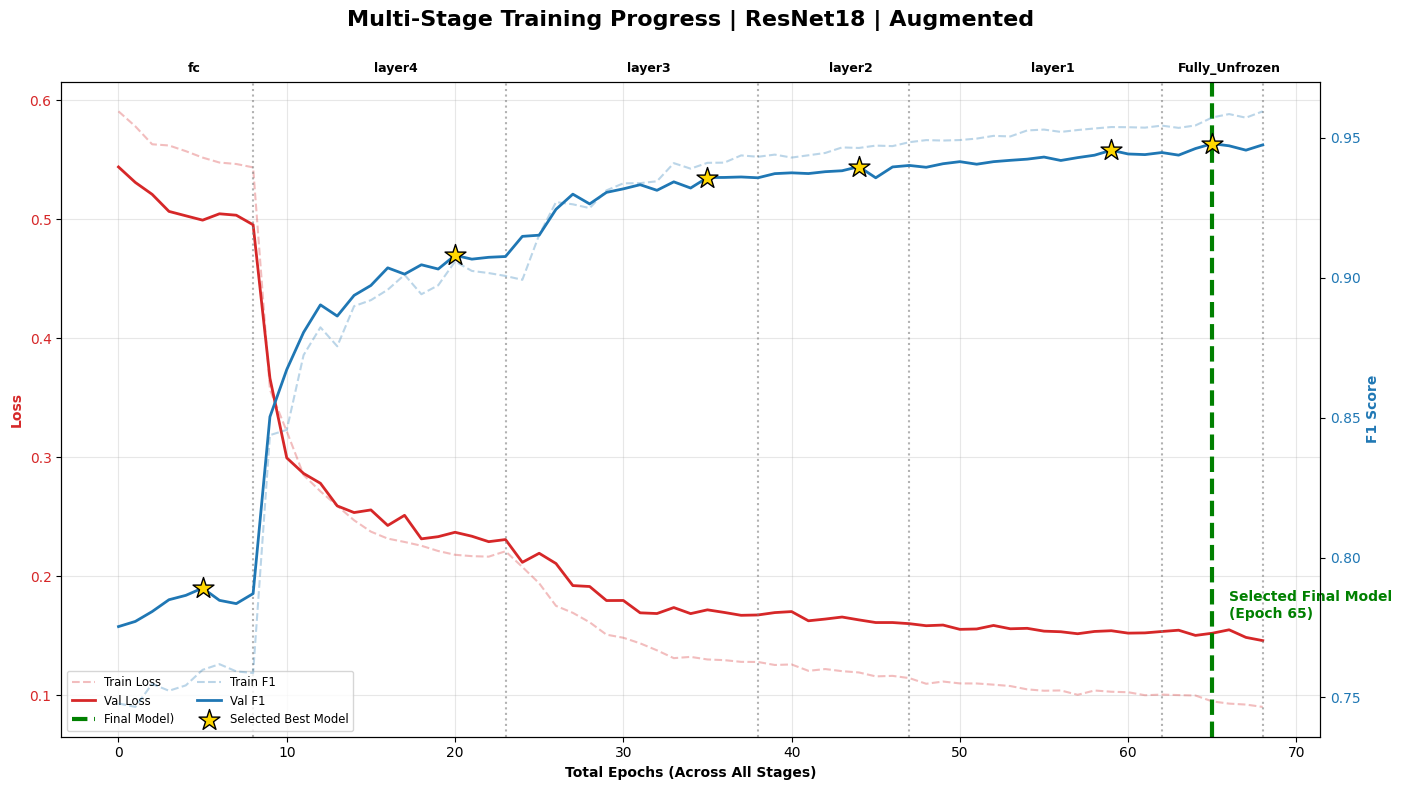

In [ ]:
#  Generate the plot again to show best model
utils.plot_multi_stage_metrics(
    metrics=metrics_dict,
    stages=stages,
    model_name='ResNet18',
    is_augmented=True
)

target_epoch = 65
ax1 = plt.gcf().axes[0]  # Get the Loss axis
ax2 = plt.gcf().axes[1]  # Get the F1 axis

# Draw the selection line
line_selection = ax1.axvline(x=target_epoch, color='green', linestyle='--',
                             linewidth=3, label='Final Model)')

# Add the text annotation
ax1.text(target_epoch + 1, ax1.get_ylim()[0] + 0.1, 'Selected Final Model\n(Epoch 65)',
         color='green', fontweight='bold')

# Gather all handles and labels from both axes
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

# Remove the old legend if it exists to prevent ghosting
if ax1.get_legend(): ax1.get_legend().remove()
if ax2.get_legend(): ax2.get_legend().remove()

# Create one final combined legend on ax1 or ax2
ax1.legend(h1 + h2, l1 + l2, loc='lower left', ncol=2, fontsize='small', frameon=True)

# Save and show
os.makedirs(path_plots, exist_ok=True)
full_path =  f"{path_plots}/Learning_Curves_Combined.png"
plt.savefig(full_path, bbox_inches='tight', dpi=300)
print(f"Plot saved to: {path_plots}")
plt.show()

In [ ]:
# Define paths
# Epoch 65 is concidentally the best model saved already
model_path = os.path.join(path_oct_models, "resnet18_None_aug_best.pth")
os.makedirs(path_final_models, exist_ok=True)
final_model_save_path = os.path.join(path_final_models, "resnet_augmented_final.pth")

if os.path.exists(model_path):
    final_model = torch.load(model_path, map_location='cpu')

    # Save as your final model file
    torch.save(final_model, final_model_save_path)

    print(f"Successfully extracted Epoch 41 from stage 'features.denseblock3'.")
    print(f"Final model saved to: {final_model_save_path}")
else:
    print(f"Error: Could not find the file at {model_path}")

Successfully extracted Epoch 41 from stage 'features.denseblock3'.
Final model saved to: /content/drive/MyDrive/Final_Models/resnet_augmented_final.pth


In [ ]:
# Evaluate the final model on the validation split
final_model_state_dict = torch.load(os.path.join(path_final_models, "resnet_augmented_final.pth"), map_location=device)
model.load_state_dict(final_model_state_dict)
final_model = copy.deepcopy(model)

results = utils.evaluate_val_split(final_model, val_loader, device, model_name,  path_final_models)

Evaluating: resnet: 100%|██████████| 33/33 [00:56<00:00,  1.71s/it]


In [ ]:
print(results['report'])